Student name: Talha Rizwan<br>
Student number: 2509714 <br>
02, 04, 2026  <br>

# Exercise 1 | TKO_7092 Evaluation of Machine Learning Methods 2026

### Case study: Metal ion concentration prediction (video lectures, slides and scripts in MOOC2) 

#### Prediction of the metal ion content from multi-parameter data
<b> Use K-Nearest Neighbor Regression with euclidean distance to predict total metal concentration (c_total), concentration of Cadmium (Cd) and concentration of Lead (Pb), using number of neighbors k = 1, 3, 5, 7.</b>

    - Please use Nearest Neighbor Regression from https://scikit-learn.org/stable/modules/neighbors.html   
    - Implement Leave-One-Out cross-validation and calculate the C-index for each output (c_total, Cd, Pb). 
    - Implement Leave-Replicas-Out cross-validation and calculate the C-index for each output (c_total, Cd, Pb).
    - Return your solution as a Jupyter Notebook (.ipynb) and as a PDF file generated from it. Please, add your full name to the file name.
    - Make sure that the code is runnable as is.
    - If AI was used, please explain at the end of the notebook, in the "AI usage disclaimer" section, how and in which parts it was applied.
    - The exercise will be graded as pass/fail.
    - Submit to moodle your solution on ** Wednesday 4 of February ** at the latest.
  
<b>Please be aware that you are required to submit your individual solution.<br> 
Submissions with identical or similar code will result in a failure for the exercise.</b>

## Import libraries

In [2]:
# In this cell import all libraries you need. For example: 
import numpy as np
import pandas as pd
from scipy.stats import somersd
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt

## Read and visualize the dataset

<p> <b>Note:</b> This dataset differs slightly from the one used in the video lectures. <br>
<b>In this dataset, some mixtures have 3 replicas, while others have 4 replicas. </b> </p> 

In the following cell: 
- Read the file water_data.csv
- Print the dimesions of the dataset (i.e. number of rows and columns) and display the first 5 rows.
- Identify the inputs and the outputs columns.
- Provide the number of mixtures with 3 replicas and 4 replicas, respectively.

In [3]:
data = pd.read_csv('water_data.csv')

print(f"Dataset dimensions: {data.shape[0]} rows, {data.shape[1]} columns")

print("\nFirst 5 rows:")
display(data.head())

input_columns = ['Mod1', 'Mod2', 'Mod3']
output_columns = ['c_total', 'Cd', 'Pb']
print(f"\nInput columns: {input_columns}")
print(f"Output columns: {output_columns}")

X = data[input_columns].values
y = data[output_columns].values

data['mixture_id'] = data.groupby(output_columns).ngroup()

replica_counts = data.groupby('mixture_id').size()
mixtures_with_3_replicas = (replica_counts == 3).sum()
mixtures_with_4_replicas = (replica_counts == 4).sum()

print(f"\nNumber of unique mixtures: {data['mixture_id'].nunique()}")
print(f"Mixtures with 3 replicas: {mixtures_with_3_replicas}")
print(f"Mixtures with 4 replicas: {mixtures_with_4_replicas}")

Dataset dimensions: 243 rows, 6 columns

First 5 rows:


,Mod1,Mod2,Mod3,c_total,Cd,Pb
0,-0.994673,-0.662192,0.327797,14.0,2.8,11.2
1,-0.982196,-0.662465,0.976950,14.0,0.0,14.0
2,2.063228,2.552820,1.681019,200.0,200.0,0.0
3,-0.839376,-0.586206,-1.471322,5000.0,3000.0,2000.0
4,-0.846858,-0.543135,-1.404644,5000.0,4000.0,1000.0



Input columns: ['Mod1', 'Mod2', 'Mod3']
Output columns: ['c_total', 'Cd', 'Pb']

Number of unique mixtures: 67
Mixtures with 3 replicas: 25
Mixtures with 4 replicas: 42


## C-index code 

In [4]:
def cindex(true, pred):
    s_d = somersd(true, y=pred, alternative='two-sided')
    c_index = (s_d.statistic + 1.0)/2.0
    return c_index

## Leave-One-Out cross-validation

In [5]:
k_values = [1, 3, 5, 7]
output_names = ['c_total', 'Cd', 'Pb']

loocv_results = {output: [] for output in output_names}

n_samples = X.shape[0]

for k in k_values:
    for out_idx, out_name in enumerate(output_names):
        y_true = []
        y_pred = []
        
        for i in range(n_samples):
            X_train = np.delete(X, i, axis=0)
            y_train = np.delete(y[:, out_idx], i)
            X_test = X[i:i+1]
            y_test = y[i, out_idx]
            
            knn = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
            knn.fit(X_train, y_train)
            
            pred = knn.predict(X_test)[0]
            
            y_true.append(y_test)
            y_pred.append(pred)
        
        c_idx = cindex(np.array(y_true), np.array(y_pred))
        loocv_results[out_name].append(c_idx)

print("Leave-One-Out Cross-Validation Results (C-index):")
print("-" * 50)
print(f"{'k':<5} {'c_total':<12} {'Cd':<12} {'Pb':<12}")
print("-" * 50)
for i, k in enumerate(k_values):
    print(f"{k:<5} {loocv_results['c_total'][i]:<12.4f} {loocv_results['Cd'][i]:<12.4f} {loocv_results['Pb'][i]:<12.4f}")

Leave-One-Out Cross-Validation Results (C-index):
--------------------------------------------------
k     c_total      Cd           Pb          
--------------------------------------------------
1     0.9122       0.9194       0.8836      
3     0.9108       0.9030       0.8772      
5     0.8912       0.8558       0.8508      
7     0.8786       0.8242       0.8298      


## Leave-Replicas-Out cross-validation

In [6]:

mixture_ids = data['mixture_id'].values
unique_mixtures = np.unique(mixture_ids)

lrocv_results = {output: [] for output in output_names}

for k in k_values:
    for out_idx, out_name in enumerate(output_names):
        y_true = []
        y_pred = []
        
        for mixture in unique_mixtures:
            test_mask = mixture_ids == mixture
            train_mask = ~test_mask
            
            X_train = X[train_mask]
            y_train = y[train_mask, out_idx]
            X_test = X[test_mask]
            y_test = y[test_mask, out_idx]
            
            knn = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
            knn.fit(X_train, y_train)
            
            preds = knn.predict(X_test)
            
            y_true.extend(y_test)
            y_pred.extend(preds)
        
        c_idx = cindex(np.array(y_true), np.array(y_pred))
        lrocv_results[out_name].append(c_idx)

print("Leave-Replicas-Out Cross-Validation Results (C-index):")
print("-" * 50)
print(f"{'k':<5} {'c_total':<12} {'Cd':<12} {'Pb':<12}")
print("-" * 50)
for i, k in enumerate(k_values):
    print(f"{k:<5} {lrocv_results['c_total'][i]:<12.4f} {lrocv_results['Cd'][i]:<12.4f} {lrocv_results['Pb'][i]:<12.4f}")

Leave-Replicas-Out Cross-Validation Results (C-index):
--------------------------------------------------
k     c_total      Cd           Pb          
--------------------------------------------------
1     0.8218       0.7553       0.7534      
3     0.8101       0.7593       0.7551      
5     0.8133       0.7427       0.7464      
7     0.8158       0.7412       0.7483      


## Compare Leave-One-Out and Leave-Replicas-Out Results

Plot the results as they were presented in the video lecture (refer to MOOC2-Module 2 .pptx slides).

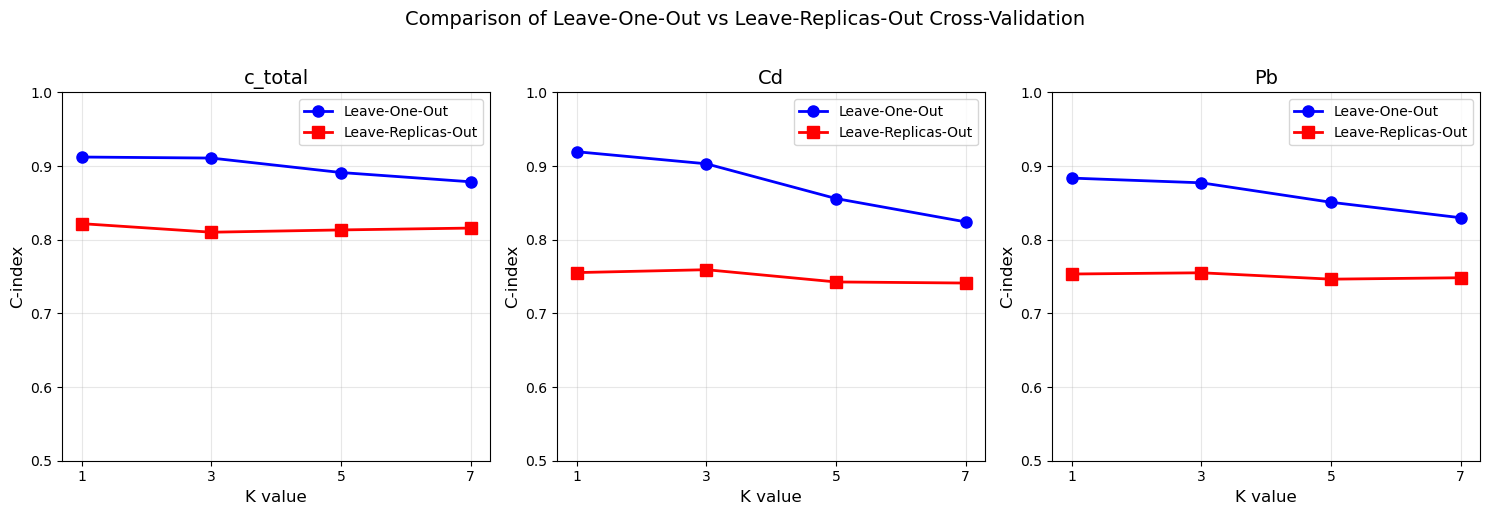

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, out_name in enumerate(output_names):
    ax = axes[idx]
    
    ax.plot(k_values, loocv_results[out_name], 'b-o', label='Leave-One-Out', linewidth=2, markersize=8)
    
    ax.plot(k_values, lrocv_results[out_name], 'r-s', label='Leave-Replicas-Out', linewidth=2, markersize=8)
    
    ax.set_xlabel('K value', fontsize=12)
    ax.set_ylabel('C-index', fontsize=12)
    ax.set_title(f'{out_name}', fontsize=14)
    ax.set_xticks(k_values)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.5, 1.0])

plt.suptitle('Comparison of Leave-One-Out vs Leave-Replicas-Out Cross-Validation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Interpretation of results
#### Answer the following questions based on the results obtained
1. Which cross-validation approach produced more optimistic results, and why?
2. Which cross-validation method provides a better estimate of the model's performance on unseen mixtures? Explain your answer.

#### Answers:

**1. Which cross-validation approach produced more optimistic results, and why?**

Leave-One-Out Cross-Validation produced more optimistic higher C-index results compared to Leave-Replicas-Out Cross-Validation. This happens because in Leave one out, replicas of the same mixture can appear in both training and test sets. Since replicas of the same mixture have identical output values but similar input values due to measurement noise, the model can "learn" from replicas in training and predict similar replicas in testing. This leads to data leakage, where information about the test sample indirectly exists in the training data, resulting in overly optimistic performance estimates.

**2. Which cross-validation method provides a better estimate of the model's performance on unseen mixtures? Explain your answer.**

Leave-Replicas-Out Cross-Validation provides a better estimate of the model's performance on truly unseen mixtures. In Leave Replicas Out, all replicas of a given mixture are held out together during testing, ensuring that the model is evaluated on completely new mixtures it has never seen during training. This experiments a more realistic scenario where we want to predict metal concentrations for new, unknown water samples. Leave replicas out prevents information leakage between training and test sets that occurs in leave one out when replicas are split, due to this providing a more honest and generalizable assessment of the model's predictive ability on new data.

## AI usage disclaimer

AI is used mostly for syntax and clearing out the outputs etc.
Moreover AI is also used for refreshing on how the Leave one out and Leave Replicas out algorithms work and their pesudo code.
I also took help of AI in plotting to plot like in MOOC2 Moudle 2 slides 2.2.4